# Simplex-Tree Experiments on the Wine Quality (Red + White combined, all quality classes, MLP) Dataset

**Setup.** Wine Quality (red + white combined) -> 11 numerical features, scale to [0,1], target quality is integer 3..9. **No reduction:** every quality level is kept as its own class (7 classes, no binning) and all 11 raw features are fed directly to a multiclass **MLP** (softmax) -- no PCA, no feature selection. Build a multiclass simplex-tree surrogate (`LinearSVC` OvR, one hyperplane per class) and find the **non-convex** parts of its decision boundary by iterating over every hyperplane.

**Experiment 1.** Remove the non-convex simplices -> the surrogate's **generalisation coefficient goes up**.

**Experiment 2.** At a non-convex point, follow LIME's vector for the NN's predicted class. Because the region is non-convex, the NN **leaves the target class** along that direction even though LIME claims it goes deeper into it. The convex contrast point obeys LIME.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

# Make the packages importable regardless of where the kernel was launched:
# walk up to the repo root (the folder that CONTAINS the in2D package), and add
# both it and the folder holding paper_experiments_utils.py to sys.path.
import glob
here = os.getcwd()
project_root = os.path.abspath(here)
while project_root != os.path.dirname(project_root) and not os.path.isdir(os.path.join(project_root, 'in2D')):
    project_root = os.path.dirname(project_root)
_paths = [project_root, here]
for p in _paths:
    p = os.path.abspath(p)
    if p not in sys.path:
        sys.path.insert(0, p)

from simplex_tree_classifier import SimplexTreeClassifier
# create_simplex_vertices removed: the package builds the enclosing simplex from n_features
from nn_utils import (
    FeatureMLP, train_nn, predict_classes, predict_proba,
    find_nonconvex_leaves, build_convex_surrogate,
    leaf_key_for_point, gen_coef,
    make_lime_explainer, lime_direction, push_along_lime)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# ---- disk cache: save anything slow to recompute so re-runs load instead ----
# Everything expensive (models, surrogates, non-convex detection, LIME results)
# is pickled under models/ and reloaded on the next run. Delete a file in
# models/ to force that step to recompute.
import pickle as _pickle
CACHE_DIR = os.path.join(os.getcwd(), 'models')
def cache_load(name):
    """Return the object cached under models/<name>, or None if absent."""
    p = os.path.join(CACHE_DIR, name)
    if os.path.exists(p):
        with open(p, 'rb') as _f:
            obj = _pickle.load(_f)
        print(f'cache hit  <- {p}')
        return obj
    return None
def cache_save(name, obj):
    """Pickle obj to models/<name> and return it."""
    os.makedirs(CACHE_DIR, exist_ok=True)
    p = os.path.join(CACHE_DIR, name)
    with open(p, 'wb') as _f:
        _pickle.dump(obj, _f)
    print(f'cache save -> {p}')
    return obj


device: cpu


### 1. Load & preprocess (raw features, all quality classes -- nothing reduced)

In [2]:
wr = fetch_openml(name='wine-quality-red',   version=1, as_frame=True, parser='auto')
ww = fetch_openml(name='wine-quality-white', version=1, as_frame=True, parser='auto')
# White wine uses generic names V1..V11 -- align column order to red
# (both UCI files have the same 11 features in the same order).
ww_aligned = ww.data.copy()
ww_aligned.columns = wr.data.columns
df = pd.concat([wr.data, ww_aligned], ignore_index=True)
quality = pd.concat([wr.target.astype(int), ww.target.astype(int)], ignore_index=True).values

classes_sorted = np.unique(quality)
y = np.searchsorted(classes_sorted, quality).astype(int)
class_names = [str(int(q)) for q in classes_sorted]
print(f'Combined shape: {df.shape}  Quality range: {quality.min()}-{quality.max()}')
print(f'Classes (raw quality scores): {class_names}')
print(f'Class counts: {dict(zip(class_names, np.bincount(y, minlength=len(classes_sorted)).tolist()))}')

X_all = MinMaxScaler().fit_transform(df.values.astype(np.float64))
all_feature_names = list(df.columns)
feature_names = all_feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

n_features = X_train.shape[1]
n_classes  = len(classes_sorted)

# Surrogate depth is capped by a leaf budget: leaves grow as
# (n_features + 1) ** subdivision_levels, so with every raw feature kept we take
# the deepest tree that stays under the budget (keeps high-D notebooks tractable).
LEAF_BUDGET = 2000
SUBDIVISION_LEVELS = max(1, int(np.log(LEAF_BUDGET) / np.log(n_features + 1)))

print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)} '
      f'| {n_features} features | {n_classes} classes')
print(f'subdivision_levels={SUBDIVISION_LEVELS} '
      f'(leaf budget {LEAF_BUDGET}, ~{(n_features+1)**SUBDIVISION_LEVELS} leaves)')


Combined shape: (6497, 11)  Quality range: 1-8
Classes (raw quality scores): ['1', '2', '3', '4', '5', '6', '7', '8']
Class counts: {'1': 20, '2': 163, '3': 1467, '4': 2251, '5': 1561, '6': 813, '7': 204, '8': 18}
6497 samples | Train 5197 | Test 1300 | 11 features | 8 classes
subdivision_levels=3 (leaf budget 2000, ~1728 leaves)


### 2. Train the MLP

All 11 raw features -> feed-forward MLP (2 hidden layers of 64, ReLU) -> softmax over the 7 quality classes. No PCA, no feature selection, no class binning -- every feature and every quality level is kept. First look at the learning curve to choose the epoch / LR budget, then fit the model the rest of the notebook uses.

Best validation accuracy: 0.5754 (epoch 46/300)


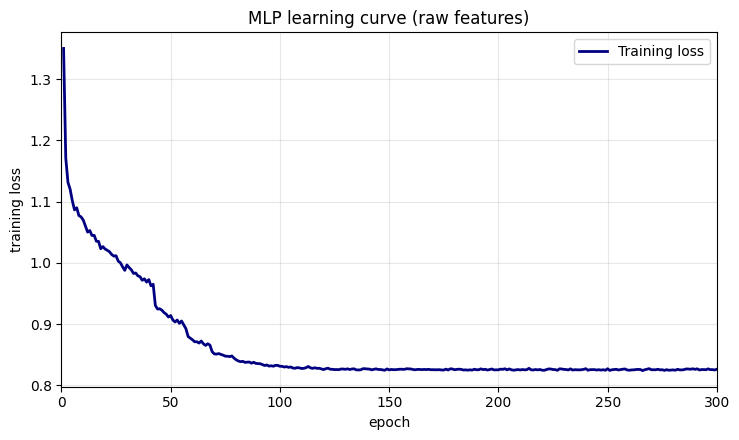

In [3]:
# EXPLORE before committing: train a throwaway MLP and plot its training-loss curve so
# you can pick the epoch / LR budget for the model the notebook actually fits below.
# Trains fresh every run (no disk cache) so the curve always reflects the params here.
CURVE_EPOCHS, CURVE_LR, CURVE_BATCH = 300, 0.01, 32
n_classes = len(np.unique(y_train))
torch.manual_seed(42); np.random.seed(42)
curve_model = FeatureMLP(n_features, n_classes=n_classes, hidden=64).to(device)
train_nn(curve_model, X_train, y_train, X_test, y_test,
         epochs=CURVE_EPOCHS, lr=CURVE_LR, batch_size=CURVE_BATCH, device=device)
loss_history = curve_model.loss_history

epochs_axis = range(1, len(loss_history) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(epochs_axis, loss_history, color='navy', lw=2, label='Training loss')
ax.set_xlim(0, CURVE_EPOCHS); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
ax.set_title('MLP learning curve (raw features)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [4]:
# Fit the model the notebook uses. Copy the epoch / LR budget you settled on from the
# learning curve above. Loads models/wine_mlp_raw.pt if present; delete that file to
# retrain after changing these.
EPOCHS, BATCH_SIZE, LR = 200, 32, 0.01
n_classes = len(np.unique(y_train))
torch.manual_seed(42); np.random.seed(42)

nn_model = FeatureMLP(n_features, n_classes=n_classes, hidden=64).to(device)
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'wine_mlp_raw.pt')
nn_loaded = os.path.exists(model_path)
if nn_loaded:
    ckpt = torch.load(model_path, map_location=device)
    nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
    if ckpt.get('loss_history') is not None:
        nn_model.loss_history = ckpt['loss_history']
    print(f'Loaded NN <- {model_path}')
else:
    t0 = time.time()
    train_nn(nn_model, X_train, y_train, X_test, y_test,
             epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, device=device)
    print(f'NN trained in {time.time()-t0:.1f}s')

nn_pred = lambda Z: predict_classes(nn_model, Z, device=device)
print(f'NN train acc: {accuracy_score(y_train, nn_pred(X_train)):.4f}')
print(f'NN test  acc: {accuracy_score(y_test,  nn_pred(X_test)):.4f}')

Loaded NN <- /home/yasmin/SimplexTreeClassifier/in2D/experiments_with_package/models/wine_mlp_raw.pt
NN train acc: 0.6685
NN test  acc: 0.5923


### Save the trained MLP

Cache the fitted network to `models/wine_mlp_raw.pt` (state dict + config) so later runs load it instead of retraining. Delete that file to force a fresh fit.

In [5]:
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'wine_mlp_raw.pt')
if globals().get('nn_loaded', False):
    print(f'NN loaded from cache; not re-saving ({model_path})')
else:
    os.makedirs(MODEL_DIR, exist_ok=True)
    torch.save({
        'class': type(nn_model).__name__,
        'state_dict': nn_model.state_dict(),
        'config': dict(d=n_features, n_classes=n_classes, hidden=64),
        'feature_names': globals().get('feature_names'),
        'class_names': globals().get('class_names'),
        'loss_history': getattr(nn_model, 'loss_history', None),
    }, model_path)
    print(f'Saved NN -> {model_path}')


NN loaded from cache; not re-saving (/home/yasmin/SimplexTreeClassifier/in2D/experiments_with_package/models/wine_mlp_raw.pt)


### 3. Build the simplex-tree surrogate

Fill `[0,1]^d` with random points labelled by the MLP, then add the real train points so every class is represented. The simplex tree (LinearSVC head, OvR-multiclass when n_classes>2) is trained on this fill set.

In [6]:
# The surrogate fill is created INSIDE the classifier now (surrogate mode): the
# package samples n_fill points in [0,1]^d, appends the train set we pass to
# fit(), and labels everything with the MLP -- so there is no manual fill /
# nn_pred() construction here anymore (see the surrogate cell below).
N_FILL, C_PARAM = 5000, 10000


### Accuracy vs subdivision levels

Sweep the surrogate's `subdivision_levels` and plot the test agreement with the NN and the test accuracy against true labels.

subdivision_levels=1: leaves=    12  agreement-with-NN=0.5746  acc-vs-labels=0.4531
subdivision_levels=2: leaves=   144  agreement-with-NN=0.6031  acc-vs-labels=0.4631
subdivision_levels=3: leaves=  1728  agreement-with-NN=0.6285  acc-vs-labels=0.4808
subdivision_levels=4: leaves= 20736  agreement-with-NN=0.6700  acc-vs-labels=0.4954

Highest agreement with NN at subdivision level 4 (= 0.6700)


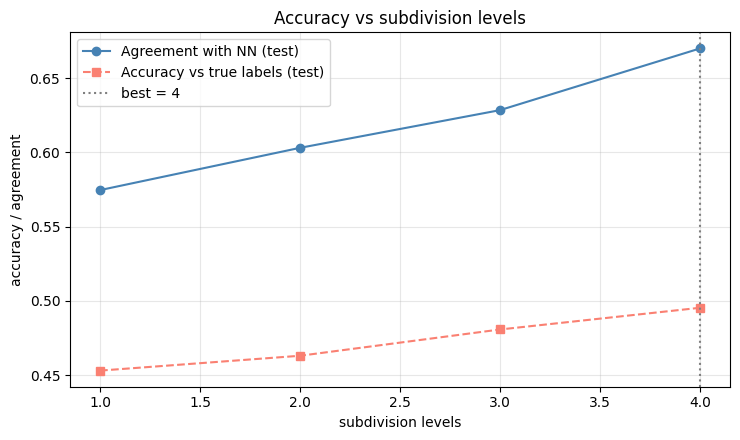

In [7]:
# Sweep subdivision_levels and report (a) surrogate-NN agreement on the test
# set, (b) surrogate accuracy on the true labels.
sub_levels = list(range(1, SUBDIVISION_LEVELS + 2))   # sweep around the budgeted depth
agree_with_nn, acc_vs_labels = [], []
y_nn_te = nn_pred(X_test)
for L in sub_levels:
    m = SimplexTreeClassifier(
        model=nn_pred, n_features=n_features, n_fill=N_FILL, margin=0.0,
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=L, random_state=42)
    m.fit(X_train)
    agree_with_nn.append(accuracy_score(y_nn_te, m.predict(X_test)))
    acc_vs_labels.append(accuracy_score(y_test, m.predict(X_test)))
    print(f'subdivision_levels={L}: leaves={len(m.leaf_simplexes):6d}  '
          f'agreement-with-NN={agree_with_nn[-1]:.4f}  '
          f'acc-vs-labels={acc_vs_labels[-1]:.4f}')

best_i = int(np.argmax(agree_with_nn))
print(f'\nHighest agreement with NN at subdivision level {sub_levels[best_i]} '
      f'(= {agree_with_nn[best_i]:.4f})')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sub_levels, agree_with_nn, 'o-', color='steelblue',
        label='Agreement with NN (test)')
ax.plot(sub_levels, acc_vs_labels, 's--', color='salmon',
        label='Accuracy vs true labels (test)')
ax.axvline(sub_levels[best_i], color='gray', ls=':',
           label=f'best = {sub_levels[best_i]}')
ax.set_xlabel('subdivision levels')
ax.set_ylabel('accuracy / agreement')
ax.set_title('Accuracy vs subdivision levels')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Initial surrogate at the budgeted subdivision level

`subdivision_levels` is chosen from the leaf budget above (deepest tree with `(n_features+1)**levels <= LEAF_BUDGET`). This is deep enough that the surrogate starts to **overfit the fill points** -- exactly the regime where pruning the non-convex leaves should help -- while staying tractable now that all 11 raw features are kept.

In [8]:
import pickle
SUBDIVISION_LEVELS = 3
# Build the surrogate in SURROGATE MODE: give the constructor the model to
# imitate; the package samples/labels its own fill in [0,1]^d and appends the
# train set we pass to fit(). We drop the (unpicklable) model after fit so the
# fitted object can be cached; the pruning/predict paths don't need it.
STC_PATH = os.path.join(os.getcwd(), 'models', 'wine_stc_raw.pkl')
if os.path.exists(STC_PATH):
    with open(STC_PATH, 'rb') as f:
        stc = pickle.load(f)
    print(f'Loaded stc <- {STC_PATH}')
else:
    stc = SimplexTreeClassifier(
        model=nn_pred, n_features=n_features, n_fill=N_FILL, margin=0.0,
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS, random_state=42)
    stc.fit(X_train)
    stc.model = None
    os.makedirs(os.path.dirname(STC_PATH), exist_ok=True)
    with open(STC_PATH, 'wb') as f:
        pickle.dump(stc, f)
    print(f'Saved stc -> {STC_PATH}')

# the surrogate training set the package built (fill points + X_train, NN-labeled)
X_fill, y_fill = stc.training_data_
print(f'Surrogate training points: {len(X_fill)}   '
      f'class counts: {dict(zip(*np.unique(y_fill, return_counts=True)))}')
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Agreement (fill) = {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Agreement (test) = {accuracy_score(nn_pred(X_test), stc.predict(X_test)):.4f}')


Saved stc -> /home/yasmin/SimplexTreeClassifier/in2D/experiments_with_package/models/wine_stc_raw.pkl
Surrogate training points: 10197   class counts: {np.int64(0): np.int64(118), np.int64(1): np.int64(189), np.int64(2): np.int64(2353), np.int64(3): np.int64(3510), np.int64(4): np.int64(1793), np.int64(5): np.int64(2014), np.int64(6): np.int64(188), np.int64(7): np.int64(32)}
Surrogate leaves: 1728
Agreement (fill) = 0.6011
Agreement (test) = 0.6285


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus any neighbour for ANY of the OvR hyperplanes. `epsilon` controls strictness (smaller = only severe curvature).

In [9]:
# EPSILON: barycentric centroid fraction 1/(d+1) -- the package's own geometric
# default, so no hand-tuned probe-placement number.
EPSILON = 1.0 / (n_features + 1)

# REMOVAL_FACTOR from the DATA, not a magic number: one threshold-free pass returns
# every bend's depth (offset / shared-face length); keep the deepest quartile (bends
# past the 75th percentile). Since epsilon scales all depths together, this quantile
# cut is essentially invariant to the exact epsilon above.
_bend_depths = stc.find_nonconvex_leaves(criterion='distance', epsilon=EPSILON, removal_factor=0.0)
_dvals = np.fromiter(_bend_depths.values(), dtype=float)
REMOVAL_FACTOR = float(np.quantile(_dvals, 0.75)) if _dvals.size else 0.0

nonconvex_keys = {k for k, v in _bend_depths.items() if v > REMOVAL_FACTOR}
n_crossing = len(stc.identify_crossing_simplices())
print(f'Boundary-crossing simplices : {n_crossing}')
print(f'Non-convex simplices        : {len(nonconvex_keys)}  (epsilon={EPSILON:.3f}, removal_factor={REMOVAL_FACTOR:.3f})')

test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 1728
Non-convex simplices        : 431  (epsilon=0.083, removal_factor=0.047)
Test points inside a non-convex region: 190 / 1300


## Experiment 1 -- Non-convex removal reduces overfitting

The surrogate copies the MLP from the fill points; with too many leaves it **overfits**. We remove the non-convex simplices (deepest bend first, up to 25% of leaves) and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher = less overfitting}).$$

In [10]:
# Trim the surrogate we already built (`stc`) with the package's own non-convex
# removal -- deepest bend first, using the SAME distance criterion and data-driven
# EPSILON / REMOVAL_FACTOR as the detection cell above, refitting from the stored
# fill set after each pass. Prune a COPY so `stc` stays intact for the comparison
# below and for Experiment 2. Computed ONCE per kernel session, then reused in
# memory (run `del stc_convex` or restart the kernel to re-trim).
import copy
if 'stc_convex' not in globals():
    stc_convex = copy.deepcopy(stc)
    before = len(stc_convex.tree.get_leaves())
    removed = stc_convex.remove_nonconvex_leaves(
        criterion='distance', epsilon=EPSILON, removal_factor=REMOVAL_FACTOR,
        max_remove_frac=0.45, max_iter=50)
    print(f'Convex trim: {before} -> {len(stc_convex.tree.get_leaves())} leaves (removed {removed})')
print(f'Pruned surrogate leaves: {len(stc_convex.leaf_simplexes)}')


Convex trim: 1728 -> 947 leaves (removed 781)
Pruned surrogate leaves: 947


In [11]:
y_nn_test = nn_pred(X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))
    return train_agree, test_agree, train_agree - test_agree, test_agree / max(train_agree,1e-9), true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  '
      f'({c_gc - b_gc:+.4f}, {"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  '
      f'({c_acc - b_acc:+.4f})')


                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                               1728                  947
Train agreement (vs NN)            0.6011               0.5863
Test  agreement (vs NN)            0.6285               0.6054
Gap (train - test)                -0.0274              -0.0190
Generalisation coef.               1.0456               1.0325
Test accuracy (vs labels)          0.4808               0.4646

Generalisation coefficient: 1.0456 -> 1.0325  (-0.0131, did not improve)
Test accuracy vs labels  : 0.4808 -> 0.4646  (-0.0162)


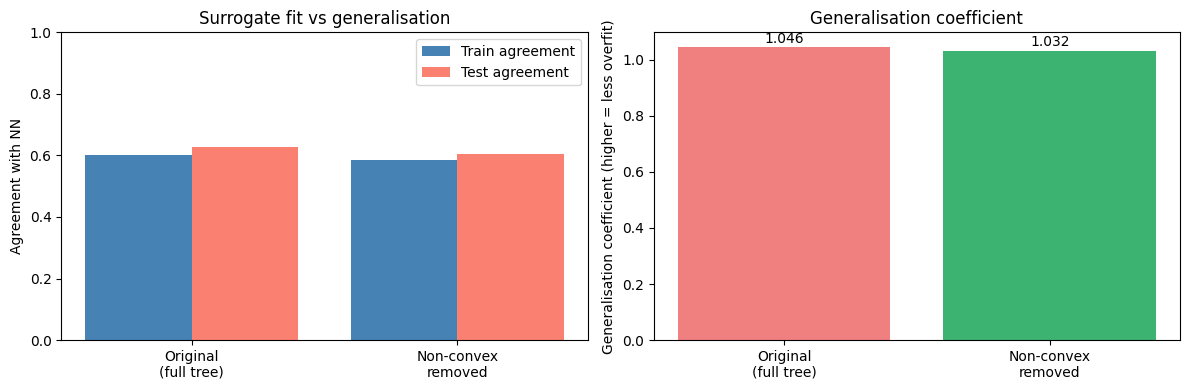

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


### Headline: the pruned surrogate vs the MLP

Same metric (true-label test / train) for both. If removal really cuts overfitting, the pruned surrogate's gen-coef should pass the MLP's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
MLP (network being explained)        0.6685   0.5923     0.8861
Simplex-tree surrogate               0.4657   0.4646     0.9978
----------------------------------------------------------------
Surrogate gen-coef 0.9978  vs  MLP gen-coef 0.8861  -> HIGHER (the surrogate overfits less than the MLP)
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.


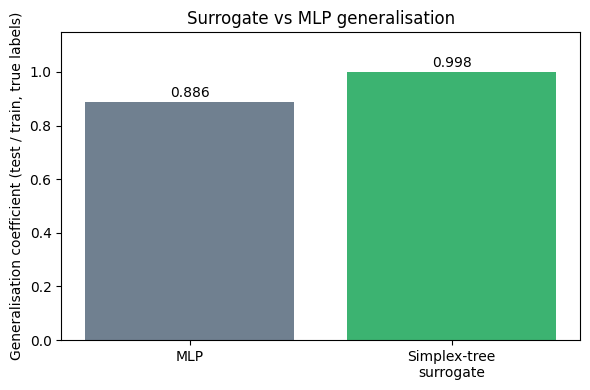

In [13]:
# Same metric (true-label test / train) for both. If pruning really cuts
# overfitting, the pruned surrogate's gen-coef should pass the MLP's.
nn_tr, nn_te, nn_gc = gen_coef(nn_pred, X_train, y_train, X_test, y_test)
p_tr,  p_te,  p_gc  = gen_coef(stc_convex.predict, X_train, y_train, X_test, y_test)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"MLP (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  MLP gen-coef {nn_gc:.4f}  -> '
      f'{"HIGHER (the surrogate overfits less than the MLP)" if p_gc > nn_gc else "lower (NN already generalises well)"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['MLP', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title('Surrogate vs MLP generalisation')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


## Experiment 2 -- LIME is faithful on the pruned surrogate but not on the NN

Take a point $x_0$ in a region where the **NN is non-convex** (found via the simplex tree) and compare
LIME's explanation of the **NN** with LIME's explanation of our **pruned simplex-tree surrogate**
(`stc_convex`, after non-convex removal) at the *same* point. For each model we fit LIME at $x_0$ for
the target class (the class the NN predicts there), read the direction LIME says increases that class,
and step along it while tracking the model's *true* $P(\text{target})$:

- **NN:** LIME claims $P(\text{target})$ only grows, but following that direction the NN's prediction
  **crosses the decision boundary** -- its argmax leaves the target class and $P(\text{target})$
  collapses. LIME's linear explanation is unfaithful here.
- **Pruned surrogate:** at the same point the surrogate is locally convex (the bend was removed), so
  $P(\text{target})$ **rises and the prediction stays in the target class** -- no crossing, LIME is
  faithful.

The **primary quantitative result** (aggregate local fidelity over all non-convex points) follows the
illustration below.

In [18]:
# LIME setup. We explain TWO models at the same point: the NN (being explained)
# and our PRUNED surrogate stc_convex (after non-convex removal). The LIME
# explainer only needs the training distribution, so one explainer serves both;
# the model enters through the proba function passed to lime_direction.
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular

# Fallback class names for notebooks that don't define them (e.g. binary +1/-1).
if 'class_names' not in globals():
    class_names = [str(c) for c in range(n_classes)]

def nn_proba(X_):
    return predict_proba(nn_model, X_, device=device)

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def stc_proba(X_):
    """SMOOTH probabilities for the pruned surrogate: softmax of its one-vs-rest
    decision_function. Smooth (unlike hard labels) so LIME can fit a meaningful
    local linear model and P(target) varies continuously along the path."""
    X_ = np.atleast_2d(np.asarray(X_, dtype=np.float64))
    d = np.asarray(stc_convex.classifier.decision_function(stc_convex.transform(X_)))
    if d.ndim == 1:                      # binary fallback
        d = np.column_stack([-d, d])
    return _softmax(d)

explainer = make_lime_explainer(X_train, feature_names, n_classes=n_classes)
ALPHA = np.linspace(0, 0.4, 81)   # LOCAL step: LIME's linear model is only
#                                    trustworthy near x0, so we compare the two
#                                    models over a short local move, not a long one.

def push(point, proba_fn, target=None):
    """Fit LIME to `proba_fn` at `point`, then step along the direction LIME says
    increases P(target) (target defaults to the model's argmax at the point).
    Returns alphas, P(target), LIME P(target), target, w, unit d, and the model's
    argmax along the whole path (int array)."""
    point = np.asarray(point, dtype=np.float32)
    if target is None:
        target = int(np.argmax(proba_fn(point)[0]))
    # Reset LIME's RNG each call so a point's explanation is REPRODUCIBLE: without
    # this the explainer's RNG advances between cells and the same point yields a
    # different direction in the readout vs the plot.
    explainer.random_state = np.random.RandomState(0)
    coef, _, lime_p_fn, grad = lime_direction(
        explainer, proba_fn, point, target_label=target, num_features=n_features)
    d = grad / max(np.linalg.norm(grad), 1e-12)
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    P = proba_fn(xs)
    return ALPHA, P[:, target], np.clip(lime_p_fn(xs), 0, 1), target, coef, d, np.argmax(P, axis=1)

def crosses_boundary(argmax_path, target):
    """True if the model's argmax LEAVES the target class anywhere on the path
    (i.e. LIME's 'increase target' step actually crosses the decision boundary)."""
    return bool((np.asarray(argmax_path) != target).any())

def first_crossing(argmax_path, target):
    """Index of the first step where the argmax leaves the target class, else None."""
    off = np.where(np.asarray(argmax_path) != target)[0]
    return int(off[0]) if off.size else None


In [19]:
if 'nonconvex_keys' not in globals():
    nonconvex_keys = set(stc.find_nonconvex_leaves(
        criterion='distance', epsilon=EPSILON, removal_factor=REMOVAL_FACTOR).keys())
# Regions still flagged non-convex in the PRUNED surrogate (used by the readout cell).
nonconvex_keys_convex = set(stc_convex.find_nonconvex_leaves(
    criterion='distance', epsilon=EPSILON, removal_factor=REMOVAL_FACTOR).keys())

# TWO demo points, each chosen for ONE job -- they need NOT be the same point:
#   x0_nn : inside a REMOVED non-convex simplex, the NN clearly STARTS in its target class
#           but following LIME's own "increase target" direction the NN LEAVES that class
#           (crosses, ideally in-and-out). This is LIME's MISTAKE, caused by non-convexity.
#   x0_stc: in a formerly-non-convex, now-pruned region, the surrogate STARTS in its class
#           and following LIME STAYS there -- no mistake, because the non-convex split was
#           removed. Defaults to x0_nn when that same point already works.
# We probe points spread across the removed simplices (centroid, vertices, edge midpoints,
# random interior mixes, nudged strictly inside) and fit LIME on each model.
if 'x0_nn' not in globals() or x0_nn is None:
    _stc_leaves  = {frozenset(l.vertex_indices): l for l in stc.tree.get_leaves()}
    _convex_keys = {frozenset(l.vertex_indices) for l in stc_convex.tree.get_leaves()}
    removed_keys = [k for k in nonconvex_keys if k in _stc_leaves and k not in _convex_keys]
    print(f'removed non-convex simplices: {len(removed_keys)}   '
          f'(original nc={len(nonconvex_keys)}, pruned nc={len(nonconvex_keys_convex)})')

    _rng   = np.random.default_rng(0)
    P_MIN  = 0.60    # a demo point must START clearly inside its class (not at ~0.5 on the boundary)
    P_SAT  = 0.985   # ... but not saturated, or there is no room to bend and cross
    BUDGET = 80      # LIME is slow; cap how many candidates we fit

    def _simplex_probe_points(V):
        V = np.asarray(V, dtype=np.float64); c = V.mean(0)
        pts = [c] + list(V)
        for a in range(len(V)):
            for b in range(a + 1, len(V)):
                pts.append(0.5 * (V[a] + V[b]))
        pts += list(_rng.dirichlet(np.ones(len(V)), size=8) @ V)
        pts = 0.9 * np.asarray(pts, dtype=np.float64) + 0.1 * c   # keep strictly inside the leaf
        return pts.astype(np.float32)

    # Probe points that START clearly (but not saturated) in the NN's class; test those in a
    # "clearly in target yet bendable" sweet spot (P ~ 0.75) first.
    probes = []
    for k in removed_keys:
        S = _simplex_probe_points(_stc_leaves[k].vertices)
        for x, s in zip(S, nn_proba(S).max(axis=1)):
            if P_MIN <= s <= P_SAT:
                probes.append((float(s), x))
    probes.sort(key=lambda t: abs(t[0] - 0.75))
    print(f'candidate points starting clearly in the NN class: {len(probes)}')

    # x0_nn: NN starts in target AND LIME makes it LEAVE the class. Score prefers the argmax
    # RETURNING to target ("in and out"), then a deeper start, then a bigger dip.
    _nn_best = None
    for s, x in probes[:BUDGET]:
        _, f_nn, _, target, _, _, am_nn = push(x, nn_proba)
        if not crosses_boundary(am_nn, target):
            continue
        score = (int(am_nn[-1] == target), float(f_nn[0]), float(f_nn[0] - f_nn.min()))
        if _nn_best is None or score > _nn_best[0]:
            _nn_best = (score, x)
    x0_nn = None if _nn_best is None else _nn_best[1]

    # x0_stc: surrogate starts in its class and STAYS (LIME faithful). Prefer x0_nn itself.
    x0_stc = None
    if x0_nn is not None:
        _, f_s, _, t_s, _, _, am_s = push(x0_nn, stc_proba)
        if f_s[0] >= 0.55 and not crosses_boundary(am_s, t_s):
            x0_stc = x0_nn
    if x0_stc is None:
        for s, x in probes[:BUDGET]:
            _, f_s, _, t_s, _, _, am_s = push(x, stc_proba)
            if f_s[0] >= P_MIN and not crosses_boundary(am_s, t_s):
                x0_stc = x
                break

    x0_demo = x0_nn   # back-compat alias
    if x0_nn is None:
        print('x0_nn : none found where the NN clearly starts in target and then LEAVES it '
              '-- raise BUDGET/ALPHA, lower P_MIN, or REMOVAL_FACTOR in the trim.')
    else:
        _, f_nn, _, t_nn, _, _, _ = push(x0_nn, nn_proba)
        print(f'x0_nn : NN target {int(t_nn)}, P(target) {f_nn[0]:.3f} -> min {f_nn.min():.3f}  '
              f'(LIME makes the NN leave target)')
        if x0_stc is None:
            print('x0_stc: none where the surrogate stays -- it may be faithful everywhere here.')
        else:
            _, f_s, _, t_s, _, _, _ = push(x0_stc, stc_proba)
            print(f'x0_stc: {"same point" if np.array_equal(x0_stc, x0_nn) else "different point"}, '
                  f'surrogate target {int(t_s)}, P(target) {f_s[0]:.3f} -> {f_s[-1]:.3f}  (LIME stays faithful)')

removed non-convex simplices: 380   (original nc=431, pruned nc=53)
candidate points starting clearly in the NN class: 2186
x0_nn : NN target 4, P(target) 0.761 -> min 0.000  (LIME makes the NN leave target)
x0_stc: different point, surrogate target 3, P(target) 0.637 -> 0.637  (LIME stays faithful)


In [20]:
# Detailed readout. LEFT job -- x0_nn: show LIME's MISTAKE on the NN. x0_nn sits inside a
# removed non-convex simplex; the NN starts clearly in its target class, yet along LIME's
# own "increase target" direction the NN LEAVES that class. RIGHT job -- x0_stc: show LIME
# is FAITHFUL on the pruned surrogate (starts in its class and stays). The two points need
# not be the same point (see the search cell).
if x0_nn is None:
    print('Skipping detailed report -- no NN demo point.')
else:
    a, f_nn, _, target, w_nn, _, am_nn = push(x0_nn, nn_proba)
    xc = first_crossing(am_nn, target); a_dip = int(np.argmin(f_nn)); other = int(am_nn[a_dip])
    print('--- NN (the mistake) -------------------------------------------------')
    print(f'x0_nn in a non-convex NN region: {leaf_key_for_point(stc, x0_nn) in nonconvex_keys}')
    print(f'NN target class = {target} ({class_names[target]})')
    print(f'NN  P(target) : start {f_nn[0]:.3f}  ->  min {f_nn[a_dip]:.3f}  ->  end {f_nn[-1]:.3f}')
    if xc is not None:
        back = 'and RETURNS to it (in and out)' if am_nn[-1] == target else 'and does NOT return'
        print(f'  NN argmax LEAVES target at alpha={a[xc]:.3f} (-> {class_names[other]}) {back}')
    else:
        print('  NN argmax never leaves the target class on this run')
    print('  => LIME points toward a NON-target region: UNFAITHFUL on the NN')
    with np.printoptions(precision=6, suppress=False, sign='+'):
        print(f'  LIME weights on NN        w = {w_nn}')

    print('\n--- pruned surrogate (no mistake) ------------------------------------')
    if x0_stc is None:
        print('No surrogate demo point where LIME stays faithful.')
    else:
        same = np.array_equal(x0_stc, x0_nn)
        _, f_st, _, t_st, w_st, _, am_st = push(x0_stc, stc_proba)
        print(f'x0_stc ({"same point as x0_nn" if same else "different point"}); convex in pruned '
              f'surrogate: {leaf_key_for_point(stc_convex, x0_stc) not in nonconvex_keys_convex}')
        print(f'STC target class = {t_st} ({class_names[t_st]})')
        print(f'STC P(target) : start {f_st[0]:.3f}  ->  end {f_st[-1]:.3f}  (change {f_st[-1]-f_st[0]:+.3f})')
        print(f'  Surrogate stays in target: {not crosses_boundary(am_st, t_st)}  => FAITHFUL on the surrogate')
        with np.printoptions(precision=6, suppress=False, sign='+'):
            print(f'  LIME weights on surrogate w = {w_st}')
        if crosses_boundary(am_nn, target) and not crosses_boundary(am_st, t_st):
            print(f'\n=> In a non-convex NN region LIME mis-points and the NN leaves its class '
                  f'(P {f_nn[0]:.2f} -> {f_nn[a_dip]:.2f}) -- unfaithful. After removing the non-convex '
                  f'split, LIME on the surrogate keeps the prediction in-class '
                  f'(P {f_st[0]:.2f} -> {f_st[-1]:.2f}) -- faithful.')

--- NN (the mistake) -------------------------------------------------
x0_nn in a non-convex NN region: True
NN target class = 4 (5)
NN  P(target) : start 0.761  ->  min 0.000  ->  end 0.000
  NN argmax LEAVES target at alpha=0.040 (-> 6) and does NOT return
  => LIME points toward a NON-target region: UNFAITHFUL on the NN
  LIME weights on NN        w = [-1.289129e-05 +2.310714e-05 +2.621563e-05 +3.382842e-05 +5.030093e-05
 +4.732504e-05 +1.481075e-05 +4.482544e-05 +8.808571e-06 +2.163123e-05
 +5.434926e-06]

--- pruned surrogate (no mistake) ------------------------------------
x0_stc (different point); convex in pruned surrogate: True
STC target class = 3 (4)
STC P(target) : start 0.637  ->  end 0.637  (change +0.000)
  Surrogate stays in target: True  => FAITHFUL on the surrogate
  LIME weights on surrogate w = [-1.318624e-59 -3.121976e-60 +6.539704e-59 +2.340807e-58 +8.503527e-60
 +1.781362e-58 +9.321039e-59 +2.205078e-59 +2.309715e-59 +7.778955e-59
 +7.728181e-60]

=> In a non-co

### LIME's mistake on the NN (non-convex) vs. LIME on the pruned surrogate

The two panels answer two questions, and each uses a point chosen **for its own job** -- they need not be
the same point:

- **Left -- NN.** At $x_0^{\mathrm{NN}}$, inside a simplex the NN makes **non-convex**, the NN *starts clearly
  inside* its predicted class. Stepping along the direction LIME says *increases* that class, the NN's true
  $P(\text{target})$ **drops and the argmax leaves the class** (shaded band) -- LIME points toward a
  non-target region, so it is **unfaithful**, precisely because the region is non-convex.
- **Right -- pruned surrogate.** At $x_0^{\mathrm{STC}}$ (a formerly-non-convex region whose split we removed)
  the surrogate is locally convex, so following LIME keeps the prediction **inside the class** -- LIME is
  **faithful**.

Titles are set from the actual curves; if the clean contrast does not occur on a run it is reported honestly.

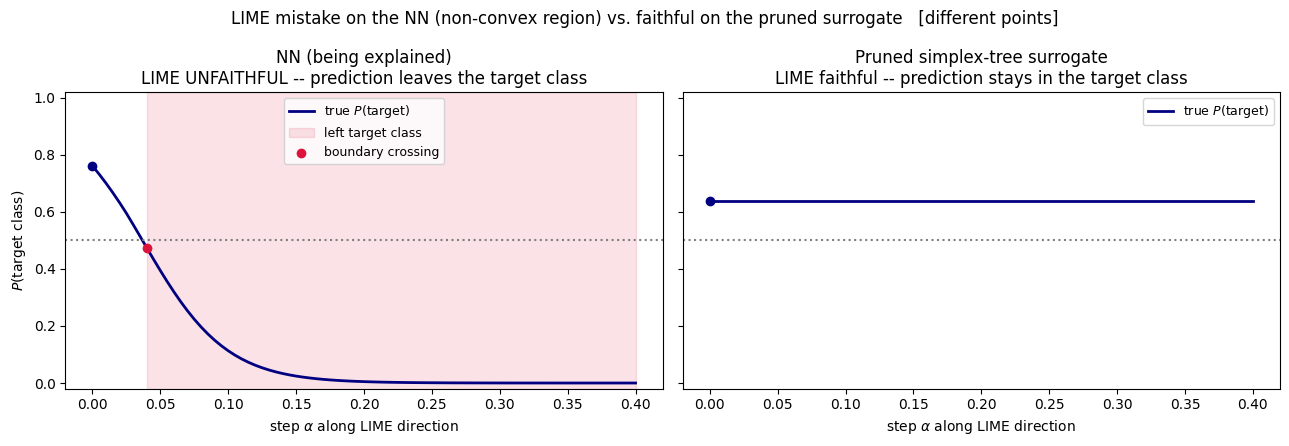

model                            start     min     end   verdict
----------------------------------------------------------------
NN (being explained)             0.761   0.000   0.000   UNFAITHFUL (leaves target)
Pruned simplex-tree surrogate    0.637   0.637   0.637   faithful (stays)


In [21]:
if x0_nn is None:
    print('No NN demo point to plot.')
else:
    panels = [('NN (being explained)', nn_proba, x0_nn)]
    if x0_stc is not None:
        panels.append(('Pruned simplex-tree surrogate', stc_proba, x0_stc))
    fig, axes = plt.subplots(1, len(panels), figsize=(6.5 * len(panels), 4.5), sharey=True)
    axes = np.atleast_1d(axes)
    summary = []
    for ax, (name, proba_fn, pt) in zip(axes, panels):
        a, f_t, _, tgt, _, _, am = push(pt, proba_fn)     # each panel uses its own model's target here
        crossed = crosses_boundary(am, tgt); xc = first_crossing(am, tgt)
        title = (f'{name}\nLIME UNFAITHFUL -- prediction leaves the target class'
                 if crossed else f'{name}\nLIME faithful -- prediction stays in the target class')
        ax.plot(a, f_t, color='navy', lw=2, label=r'true $P(\mathrm{target})$')
        off = np.asarray(am) != tgt
        if off.any():
            ax.fill_between(a, 0, 1, where=off, color='crimson', alpha=0.12,
                            transform=ax.get_xaxis_transform(), label='left target class')
        ax.axhline(0.5, color='gray', ls=':')
        ax.scatter([0], [f_t[0]], color='navy', zorder=5)
        if xc is not None:
            ax.scatter([a[xc]], [f_t[xc]], color='crimson', zorder=6, label='boundary crossing')
        ax.set_xlabel(r'step $\alpha$ along LIME direction'); ax.set_ylim(-0.02, 1.02)
        ax.set_title(title); ax.legend(loc='best', fontsize=9)
        summary.append((name, float(f_t[0]), float(f_t.min()), float(f_t[-1]), crossed))
    axes[0].set_ylabel(r'$P(\mathrm{target\ class})$')
    same = (x0_stc is not None) and np.array_equal(x0_stc, x0_nn)
    plt.suptitle('LIME mistake on the NN (non-convex region) vs. faithful on the pruned surrogate'
                 + ('   [same point]' if same else '   [different points]'))
    plt.tight_layout(); plt.show()

    hdr = f'{"model":30s} {"start":>7s} {"min":>7s} {"end":>7s}   verdict'
    print(hdr); print('-' * len(hdr))
    for name, s, mn, e, crossed in summary:
        verdict = 'UNFAITHFUL (leaves target)' if crossed else 'faithful (stays)'
        print(f'{name:30s} {s:>7.3f} {mn:>7.3f} {e:>7.3f}   {verdict}')